<a href="https://colab.research.google.com/github/tungduong2106/PracticeML/blob/main/Practice2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
path = "/content/drive/MyDrive/Colab Notebooks/elantra.csv"
df = pd.read_csv(path)

In [3]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   Month  Year  ElantraSales  Unemployment  Queries  CPI_energy  CPI_all
0      1  2010          7690           9.7      153     213.377  217.466
1      1  2011          9659           9.1      259     229.353  221.082
2      1  2012         10900           8.2      354     244.178  227.666
3      1  2013         12174           7.9      230     242.560  231.321
4      1  2014         15326           6.6      232     247.575  234.933
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Month         50 non-null     int64  
 1   Year          50 non-null     int64  
 2   ElantraSales  50 non-null     int64  
 3   Unemployment  50 non-null     float64
 4   Queries       50 non-null     int64  
 5   CPI_energy    50 non-null     float64
 6   CPI_all       50 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 2.9 KB
None
Month           0


In [4]:
df.tail(10)

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
40,10,2012,14512,7.8,257,256.389,231.652
41,10,2013,14876,7.2,223,243.374,233.782
42,11,2010,8631,9.8,161,219.303,219.544
43,11,2011,12414,8.6,255,247.092,227.136
44,11,2012,15923,7.8,246,248.136,231.190
45,11,2013,16751,7.0,231,242.301,234.033
46,12,2010,13096,9.4,170,227.190,220.437
47,12,2011,13025,8.5,253,243.015,227.093
48,12,2012,19024,7.9,275,244.698,231.099
49,12,2013,21692,6.7,279,246.189,234.594


In [5]:
df_sorted = df.sort_values(by = ['Year','Month'],ascending=True) # ascending = false thi se sap xep nguoc lai
df_sorted.reset_index(drop=True, inplace=True)
print(df_sorted)

    Month  Year  ElantraSales  Unemployment  Queries  CPI_energy  CPI_all
0       1  2010          7690           9.7      153     213.377  217.466
1       2  2010          7966           9.8      130     209.924  217.251
2       3  2010          8225           9.9      138     209.163  217.305
3       4  2010          9657           9.9      132     209.024  217.376
4       5  2010          9781           9.6      177     206.172  217.299
5       6  2010         14245           9.4      138     204.161  217.285
6       7  2010         18215           9.5      156     206.834  217.677
7       8  2010         15181           9.5      202     208.927  218.012
8       9  2010         10062           9.5      150     209.850  218.281
9      10  2010          9497           9.5      178     216.655  219.024
10     11  2010          8631           9.8      161     219.303  219.544
11     12  2010         13096           9.4      170     227.190  220.437
12      1  2011          9659         

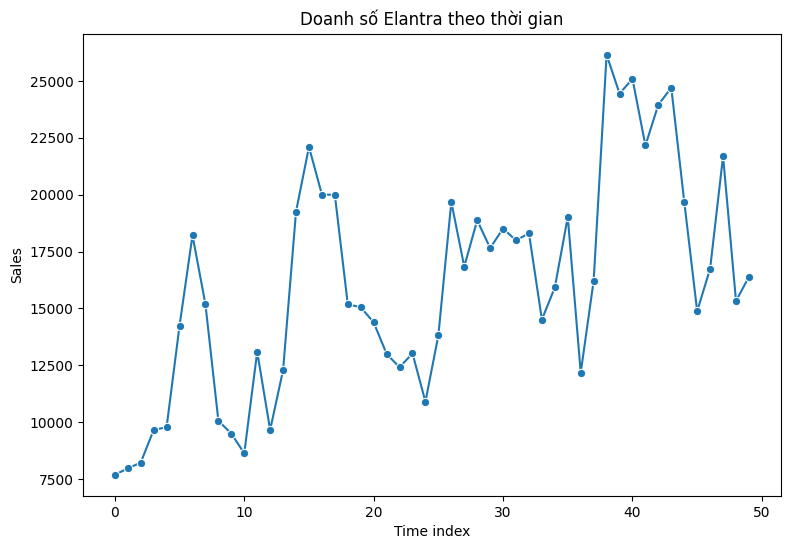

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(9,6))
sns.lineplot(df_sorted['ElantraSales'],marker="o") # Ve do thi cho ElantraSales theo thoi gian
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.title("Doanh số Elantra theo thời gian")
plt.show()

In [7]:
from numpy._core import numeric
numeric_feats = df_sorted.columns.drop(["ElantraSales","Month","Year"])
numeric_feats

Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all'], dtype='object')

In [8]:
df_train = df_sorted[df_sorted.Year < 2013]
df_test = df_sorted[df_sorted.Year >= 2013]

y_train = df_train.ElantraSales.values
y_test = df_test.ElantraSales.values

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df_train[numeric_feats])
X_train = scaler.transform(df_train[numeric_feats])
X_test = scaler.transform(df_test[numeric_feats])

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
from sklearn.metrics import mean_squared_error
def relative_error(y_true,y_pred):
  errors = np.abs(y_pred - y_true).astype(float)/ y_true
  return np.mean(errors)*100

In [12]:
y_pred = model.predict(X_test)
print ('RMSE:{:.2f}'.format(np.sqrt(mean_squared_error(y_test,y_pred))))
print ('Mean ralative errors: {:.1f}%'.format(relative_error(y_test, y_pred)))

RMSE:5017.35
Mean ralative errors: 19.0%


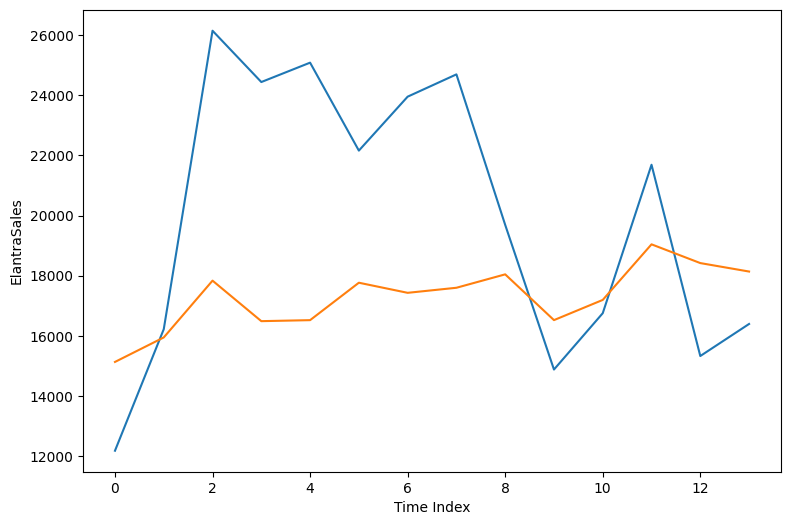

In [13]:
plt.figure(figsize=(9,6))
plt.plot(y_test)
plt.plot(y_pred)
plt.xlabel('Time Index')
plt.ylabel('ElantraSales')
plt.show()

In [14]:
month_onehot_train = pd.get_dummies(df_train.Month)
month_onehot_train.head()

,1,2,3,4,5,6,7,8,9,10,11,12
0,True,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False


In [15]:
month_onehot_test = pd.get_dummies(df_test.Month)
month_onehot_train = month_onehot_train.values
month_onehot_test = month_onehot_test.values

In [16]:
X_train_new = np.hstack((X_train, month_onehot_train))
X_test_new = np.hstack((X_test, month_onehot_test))

In [17]:
model.fit(X_train_new,y_train)

LinearRegression()

In [18]:
y_pred_new = model.predict(X_test_new)
print ('RMSE:{:.2f}'.format(np.sqrt(mean_squared_error(y_test,y_pred_new))))
print ('Mean ralative errors: {:.1f}%'.format(relative_error(y_test, y_pred_new)))
r_2 = model.score(X_test_new,y_test)
print('R-squared: {:.2f}'.format(r_2))

RMSE:3590.37
Mean ralative errors: 12.8%
R-squared: 0.35


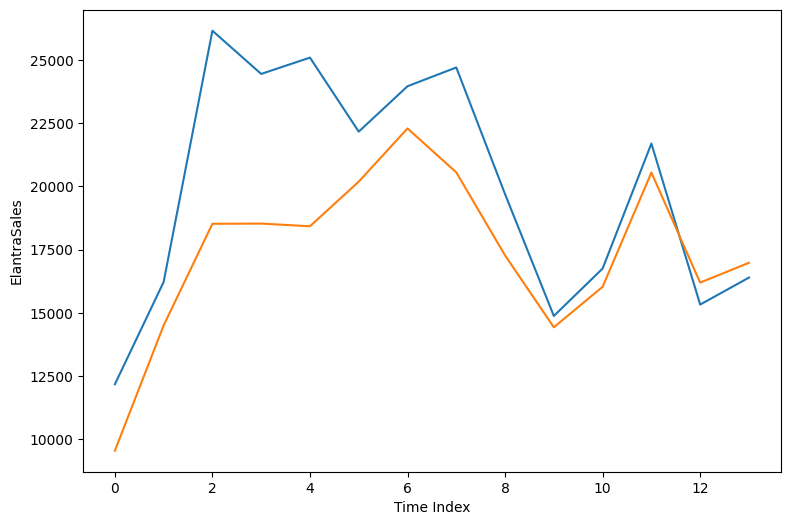

In [19]:
plt.figure(figsize=(9,6))
plt.plot(y_test)
plt.plot(y_pred_new)
plt.xlabel('Time Index')
plt.ylabel('ElantraSales')
plt.show()